# STAL paper-style tail-uplift distributions

This notebook randomly samples 1,000 readable real images and 1,000 readable AI images without replacement. For every selected image it computes the same uplift statistic for clean, JPEG-compressed, blurred, resized, and combined-degradation variants:

$$c(\rho)=\frac{r(\rho)-r(0.7)}{\ln 10},\qquad U=c(1)-\min_{\rho\geq 0.7}c(\rho).$$

Here $r$ is the radial mean log-power produced by the current lightweight STAL implementation. The same sampled images are used for every variant.

In [17]:
%matplotlib inline

import io
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

REAL_DIR = Path("/home/utakata/LLMs/techjam2026/SID/real") # path to dir of real images
AI_DIR = Path("/home/utakata/LLMs/techjam2026/SID/ai") # path to dir of AI-generated images

SAMPLES_PER_CLASS = 1000
SEED = 42
SIZE = 224
NUM_BINS = 64
TAIL_START = 0.70
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_CSV = Path("tail_uplift_results.csv")
HISTOGRAM_PATH = Path("tail_uplift_histograms.png")
AUC_PLOT_PATH = Path("tail_uplift_auc.png")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Using device: {DEVICE}")

Using device: cuda


In [18]:
def collect_image_paths(folder):
    if not folder.is_dir():
        raise FileNotFoundError(f"Image directory does not exist: {folder}")
    paths = sorted(
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    if len(paths) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"Need at least {SAMPLES_PER_CLASS} images under {folder}; "
            f"found {len(paths)}"
        )
    return paths


def load_rgb_image(path):
    with Image.open(path) as source:
        source.load()
        has_transparency = (
            source.mode in {"RGBA", "LA"}
            or (source.mode == "P" and "transparency" in source.info)
        )
        if has_transparency:
            rgba = source.convert("RGBA")
            background = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
            return Image.alpha_composite(background, rgba).convert("RGB")
        return source.convert("RGB")


def jpeg_compress(image, quality):
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    with Image.open(buffer) as compressed:
        compressed.load()
        return compressed.convert("RGB")


def gaussian_blur(image, sigma):
    kernel_size = max(3, 2 * int(3 * sigma) + 1)
    return TF.gaussian_blur(image, kernel_size=kernel_size, sigma=sigma)


def resize_roundtrip(image, scale):
    width, height = image.size
    small_width = max(1, round(width * scale))
    small_height = max(1, round(height * scale))
    small = TF.resize(
        image, [small_height, small_width],
        interpolation=InterpolationMode.BICUBIC, antialias=True,
    )
    return TF.resize(
        small, [height, width],
        interpolation=InterpolationMode.BICUBIC, antialias=True,
    )


def make_variants(image):
    blur_2 = gaussian_blur(image, 2.0)
    return {
        "clean": image,
        "jpeg_q60": jpeg_compress(image, 60),
        "jpeg_q30": jpeg_compress(image, 30),
        "blur_sigma1": gaussian_blur(image, 1.0),
        "blur_sigma2": blur_2,
        "resize_0.5": resize_roundtrip(image, 0.5),
        "blur2_jpeg30": jpeg_compress(blur_2, 30),
    }

In [19]:
class RadialLogPowerComputer:
    """Batched version of the current lightweight STAL radial spectrum."""

    def __init__(self, size, num_bins, device, eps=1e-6):
        self.size = size
        self.num_bins = num_bins
        self.device = device
        self.eps = eps

        window_1d = torch.hann_window(
            size, periodic=False, dtype=torch.float32, device=device
        )
        self.window = window_1d[:, None] * window_1d[None, :]

        coordinates = torch.arange(size, dtype=torch.float32, device=device)
        coordinates = coordinates - (size - 1) / 2
        yy, xx = torch.meshgrid(coordinates, coordinates, indexing="ij")
        radius = torch.sqrt(yy.square() + xx.square())
        radius = radius / radius.max().clamp_min(eps)
        self.bin_index = torch.clamp(
            (radius * num_bins).long(), min=0, max=num_bins - 1
        ).reshape(1, -1)
        self.counts = torch.bincount(
            self.bin_index[0], minlength=num_bins
        ).to(torch.float32)

    @torch.inference_mode()
    def __call__(self, images):
        images = images.to(self.device, non_blocking=True).float()
        luminance = (
            0.299 * images[:, 0]
            + 0.587 * images[:, 1]
            + 0.114 * images[:, 2]
        )
        luminance = luminance - luminance.mean(dim=(-2, -1), keepdim=True)
        spectrum = torch.fft.fft2(luminance * self.window, norm="ortho")
        spectrum = torch.fft.fftshift(spectrum, dim=(-2, -1))
        log_power = torch.log(spectrum.abs().square() + 1e-12)

        batch_size = images.shape[0]
        bin_index = self.bin_index.expand(batch_size, -1)
        radial_sum = torch.zeros(
            batch_size, self.num_bins,
            dtype=log_power.dtype, device=self.device,
        )
        radial_sum.scatter_add_(1, bin_index, log_power.reshape(batch_size, -1))
        radial = radial_sum / self.counts.clamp_min(1).unsqueeze(0)
        return radial.cpu().numpy()


spectrum_computer = RadialLogPowerComputer(SIZE, NUM_BINS, DEVICE)
tail_bin = min(NUM_BINS - 1, int(round(NUM_BINS * TAIL_START)))
actual_tail_boundary = tail_bin / NUM_BINS
resize_to_input = transforms.Resize((SIZE, SIZE), antialias=True)

print(f"Tail starts at bin {tail_bin}/{NUM_BINS} (rho={actual_tail_boundary:.5f})")
print(
    f"Tail-bin coefficient counts: minimum={int(spectrum_computer.counts[tail_bin:].min())}, "
    f"median={float(spectrum_computer.counts[tail_bin:].median()):.1f}"
)

Tail starts at bin 45/64 (rho=0.70312)
Tail-bin coefficient counts: minimum=40, median=520.0


In [20]:
def process_class(all_paths, class_name, label, rng):
    candidates = list(all_paths)
    rng.shuffle(candidates)
    accepted = 0
    skipped = []
    rows = []

    progress = tqdm(total=SAMPLES_PER_CLASS, desc=class_name)
    for path in candidates:
        if accepted >= SAMPLES_PER_CLASS:
            break
        try:
            image = resize_to_input(load_rgb_image(path))
            variants = make_variants(image)
            names = list(variants)
            image_batch = torch.stack([
                TF.to_tensor(variants[name]) for name in names
            ])
            raw_spectra = spectrum_computer(image_batch)

            image_rows = []
            for variant_name, raw in zip(names, raw_spectra):
                tail_curve = (
                    raw[tail_bin:] - raw[tail_bin]
                ) / np.log(10.0)
                uplift = float(tail_curve[-1] - tail_curve.min())
                image_rows.append({
                    "image_path": str(path),
                    "class_name": class_name,
                    "label": label,
                    "variant": variant_name,
                    "tail_uplift": uplift,
                    "tail_endpoint": float(tail_curve[-1]),
                    "tail_minimum": float(tail_curve.min()),
                })

            # Commit all variants together so every variant uses identical images.
            rows.extend(image_rows)
            accepted += 1
            progress.update(1)
        except Exception as error:
            skipped.append((str(path), str(error)))

    progress.close()
    if accepted < SAMPLES_PER_CLASS:
        raise RuntimeError(
            f"Only {accepted} readable {class_name} images were found"
        )
    print(f"{class_name}: accepted={accepted}, unreadable skipped={len(skipped)}")
    if skipped:
        print("First skipped file:", skipped[0])
    return rows, skipped

In [21]:
real_paths = collect_image_paths(REAL_DIR)
ai_paths = collect_image_paths(AI_DIR)
print(f"Available paths: real={len(real_paths)}, AI={len(ai_paths)}")

rng = random.Random(SEED)
real_rows, skipped_real = process_class(real_paths, "real", 0, rng)
ai_rows, skipped_ai = process_class(ai_paths, "ai", 1, rng)

results = pd.DataFrame(real_rows + ai_rows)
results.to_csv(RESULTS_CSV, index=False)
print(f"Saved {len(results):,} rows to {RESULTS_CSV}")
display(results.head())

Available paths: real=50000, AI=50000


real:   0%|          | 0/1000 [00:00<?, ?it/s]

real: accepted=1000, unreadable skipped=0


ai:   0%|          | 0/1000 [00:00<?, ?it/s]

ai: accepted=1000, unreadable skipped=0
Saved 14,000 rows to tail_uplift_results.csv


,image_path,class_name,label,variant,tail_uplift,tail_endpoint,tail_minimum
0,/home/utakata/LLMs/techjam2026/SID/real/000992...,real,0,clean,0.000000,-1.159691,-1.159691
1,/home/utakata/LLMs/techjam2026/SID/real/000992...,real,0,jpeg_q60,0.000000,-1.269111,-1.269111
2,/home/utakata/LLMs/techjam2026/SID/real/000992...,real,0,jpeg_q30,0.682392,-0.180432,-0.862824
3,/home/utakata/LLMs/techjam2026/SID/real/000992...,real,0,blur_sigma1,0.333371,0.069487,-0.263884
4,/home/utakata/LLMs/techjam2026/SID/real/000992...,real,0,blur_sigma2,0.000000,-0.275763,-0.275763


In [22]:
variant_order = list(make_variants(Image.new("RGB", (SIZE, SIZE))).keys())

summary = (
    results.groupby(["variant", "class_name"])["tail_uplift"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reindex(variant_order, level="variant")
)
display(summary.round(4))

auc_rows = []
for variant in variant_order:
    subset = results[results["variant"] == variant]
    auc = roc_auc_score(subset["label"], subset["tail_uplift"])
    real_values = subset.loc[subset["label"] == 0, "tail_uplift"].to_numpy()
    ai_values = subset.loc[subset["label"] == 1, "tail_uplift"].to_numpy()
    pooled_std = np.sqrt(
        ((len(real_values) - 1) * real_values.var(ddof=1)
         + (len(ai_values) - 1) * ai_values.var(ddof=1))
        / (len(real_values) + len(ai_values) - 2)
    )
    cohens_d = (ai_values.mean() - real_values.mean()) / max(pooled_std, 1e-12)
    auc_rows.append({
        "variant": variant,
        "AUC (AI expected higher)": auc,
        "direction-free separability": max(auc, 1 - auc),
        "Cohen's d (AI-real)": cohens_d,
    })

auc_table = pd.DataFrame(auc_rows).set_index("variant")
display(auc_table.round(4))

count    mean     std  median  min     max
variant      class_name                                            
clean        ai           1000  0.1416  0.1773  0.0685  0.0  1.1947
             real         1000  0.1219  0.1529  0.0626  0.0  0.8375
jpeg_q60     ai           1000  0.1367  0.1707  0.0622  0.0  0.9253
             real         1000  0.1165  0.1521  0.0461  0.0  0.9905
jpeg_q30     ai           1000  0.1176  0.1541  0.0447  0.0  0.7389
             real         1000  0.1082  0.1506  0.0279  0.0  0.8218
blur_sigma1  ai           1000  0.1452  0.1431  0.1207  0.0  0.7018
             real         1000  0.1437  0.1439  0.1107  0.0  0.6699
blur_sigma2  ai           1000  0.1521  0.1424  0.1350  0.0  0.7486
             real         1000  0.1398  0.1397  0.1127  0.0  0.6702
resize_0.5   ai           1000  0.1569  0.1568  0.1215  0.0  0.7217
             real         1000  0.1497  0.1495  0.1123  0.0  0.6935
blur2_jpeg30 ai           1000  0.1128  0.1390  0.0567  0.0  0.8157
             real         1000  0.1066  0.1309  0.0543  0.0  0.7055

,AUC (AI expected higher),direction-free separability,Cohen's d (AI-real)
variant,,,
clean,0.5176,0.5176,0.1191
jpeg_q60,0.5262,0.5262,0.1250
jpeg_q30,0.5195,0.5195,0.0615
blur_sigma1,0.5023,0.5023,0.0105
blur_sigma2,0.5264,0.5264,0.0868
resize_0.5,0.5101,0.5101,0.0473
blur2_jpeg30,0.5091,0.5091,0.0459


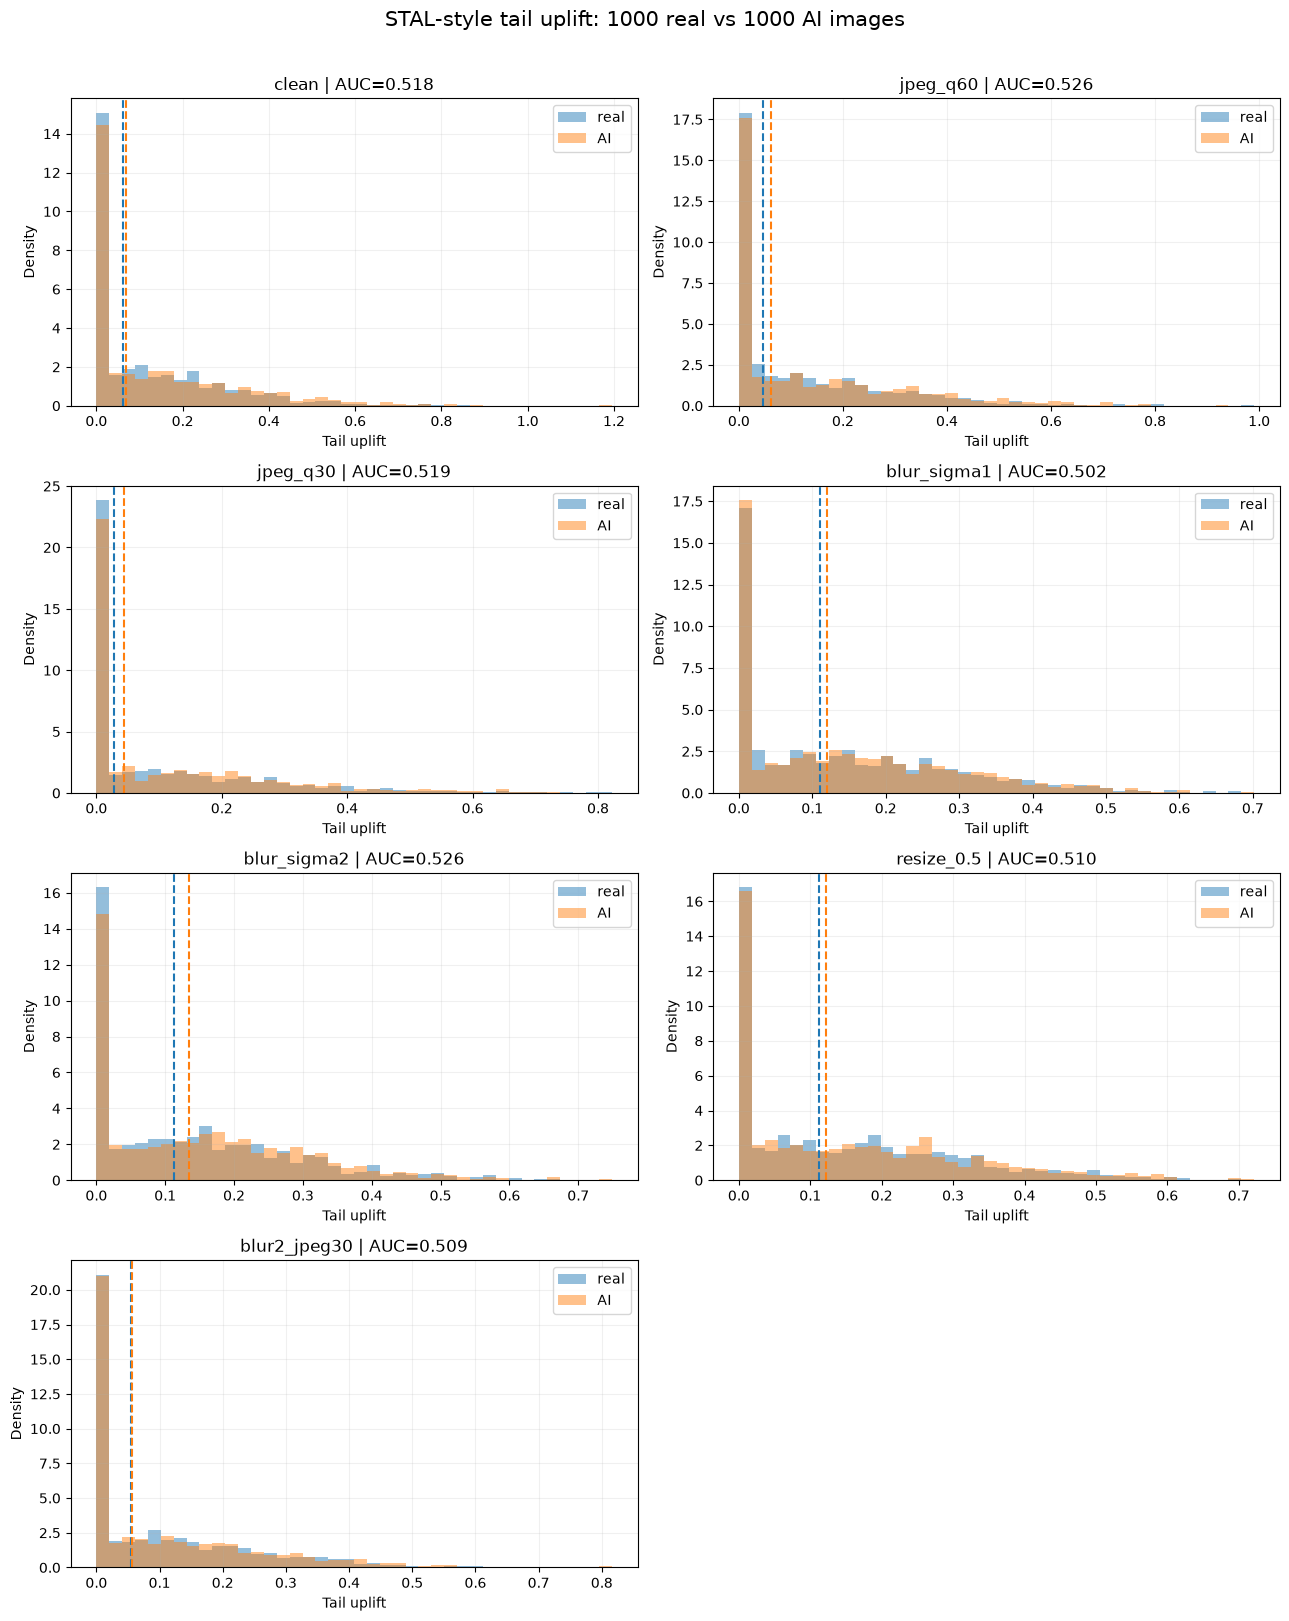

Saved histogram figure to tail_uplift_histograms.png


In [23]:
n_columns = 2
n_rows = math.ceil(len(variant_order) / n_columns)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(13, 4 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, variant in zip(axes, variant_order):
    subset = results[results["variant"] == variant]
    real_values = subset.loc[subset["class_name"] == "real", "tail_uplift"]
    ai_values = subset.loc[subset["class_name"] == "ai", "tail_uplift"]
    shared_bins = np.histogram_bin_edges(
        np.concatenate([real_values.to_numpy(), ai_values.to_numpy()]), bins=40
    )
    axis.hist(
        real_values, bins=shared_bins, density=True, alpha=0.48,
        color="tab:blue", label="real",
    )
    axis.hist(
        ai_values, bins=shared_bins, density=True, alpha=0.48,
        color="tab:orange", label="AI",
    )
    axis.axvline(real_values.median(), color="tab:blue", linestyle="--")
    axis.axvline(ai_values.median(), color="tab:orange", linestyle="--")
    auc = auc_table.loc[variant, "AUC (AI expected higher)"]
    axis.set_title(f"{variant} | AUC={auc:.3f}")
    axis.set_xlabel("Tail uplift")
    axis.set_ylabel("Density")
    axis.grid(alpha=0.18)
    axis.legend()

for axis in axes[len(variant_order):]:
    axis.axis("off")

fig.suptitle(
    f"STAL-style tail uplift: {SAMPLES_PER_CLASS} real vs {SAMPLES_PER_CLASS} AI images",
    fontsize=15, y=1.01,
)
fig.tight_layout()
fig.savefig(HISTOGRAM_PATH, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved histogram figure to {HISTOGRAM_PATH}")

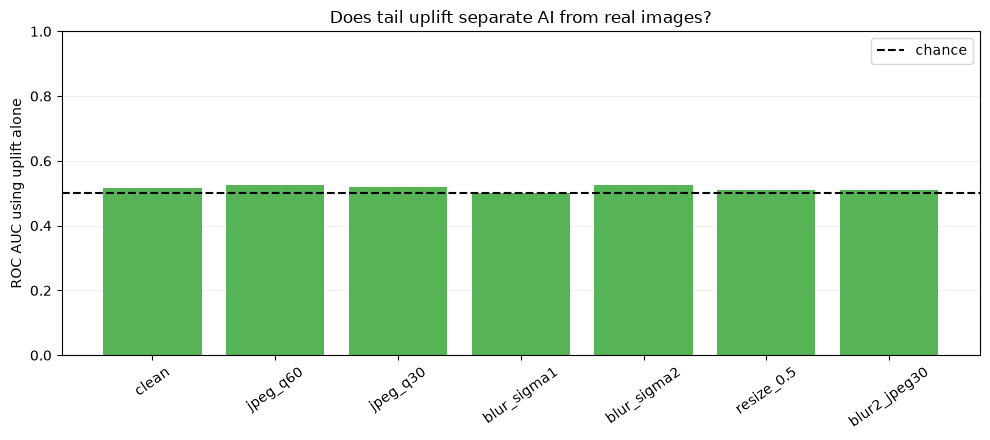

Saved AUC figure to tail_uplift_auc.png


In [8]:
fig, axis = plt.subplots(figsize=(10, 4.5))
auc_values = auc_table.loc[variant_order, "AUC (AI expected higher)"]
colors = ["tab:green" if value >= 0.5 else "tab:red" for value in auc_values]
axis.bar(variant_order, auc_values, color=colors, alpha=0.8)
axis.axhline(0.5, color="black", linestyle="--", label="chance")
axis.set_ylim(0, 1)
axis.set_ylabel("ROC AUC using uplift alone")
axis.set_title("Does tail uplift separate AI from real images?")
axis.tick_params(axis="x", rotation=35)
axis.grid(axis="y", alpha=0.2)
axis.legend()
fig.tight_layout()
fig.savefig(AUC_PLOT_PATH, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved AUC figure to {AUC_PLOT_PATH}")

## Interpretation

- AUC near **0.5** means uplift alone is not useful for separating the classes.
- AUC above **0.5** means AI images tend to have larger uplift.
- AUC below **0.5** means AI images tend to have smaller uplift—the opposite of the proposed direction.
- Compare clean and degraded AUCs. If degradation drives AUC toward 0.5 or reverses it, increasing tail supervision is unlikely to improve robustness.
- This tests the lightweight luminance-only radial statistic, not the paper's complete YCbCr + local-DCT teacher.